In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [ ]:
train = pd.read_csv('../data/train.csv')
train = train[train['building_id'] == 105]
train = train.drop(columns=['meter', 'building_id']).reset_index(drop=True)
train['timestamp'] = pd.to_datetime(train['timestamp'])

dropping the dead-flat march-late april stretch before merging weather in.


In [ ]:
bad_start, bad_end = '2016-03-01', '2016-04-20'
train = train[~train['timestamp'].between(bad_start, bad_end)].reset_index(drop=True)
train.shape

(7583, 2)

site 1 is building 105's site, loading its weather and merging on timestamp.


In [ ]:
weather = pd.read_csv('../data/weather_train.csv')
weather = weather[weather['site_id'] == 1].drop(columns=['site_id'])
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.isna().sum()


timestamp                0
air_temperature          1
cloud_coverage        7062
dew_temperature          1
precip_depth_1_hr     8763
sea_level_pressure      52
wind_direction           3
wind_speed               0
dtype: int64

cloud_coverage and precip_depth_1_hr are almost entirely missing for this site (7062 and 8763 nulls out of 8763 rows) so they're not usable - dropping them. air_temperature, dew_temperature, sea_level_pressure, wind_direction, wind_speed are basically complete, keeping those.


In [ ]:
weather = weather.drop(columns=['cloud_coverage', 'precip_depth_1_hr'])
weather = weather.ffill()  # fill the handful of remaining single-hour gaps

df = train.merge(weather, on='timestamp', how='left')
df.isna().sum()


timestamp              0
meter_reading          0
air_temperature       15
dew_temperature       15
sea_level_pressure    15
wind_direction        15
wind_speed            15
dtype: int64

### temperature vs consumption
scatter of air_temperature against meter_reading, plus the correlation number.


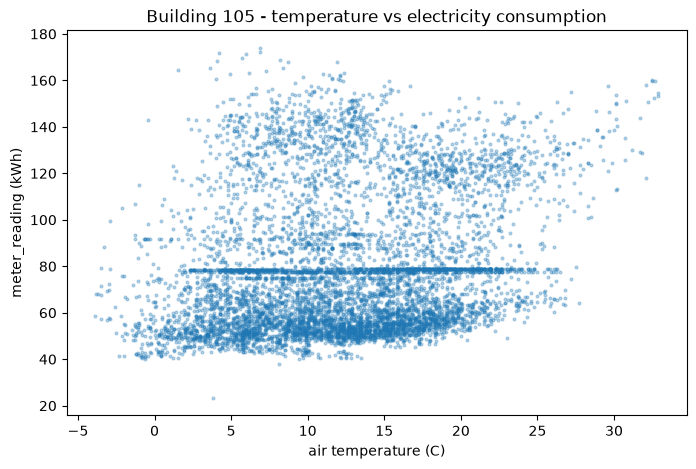

correlation: 0.22169439395706886


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df['air_temperature'], df['meter_reading'], s=4, alpha=0.3)
ax.set_xlabel('air temperature (C)')
ax.set_ylabel('meter_reading (kWh)')
ax.set_title('Building 105 - temperature vs electricity consumption')
plt.show()

print('correlation:', df['air_temperature'].corr(df['meter_reading']))


The relationship is mixed, with multiple clouds suggesting occupancy or operating hours may be affecting consumption

### temperature vs consumption, split by occupied hours
splitting into occupied (10am-5pm weekdays, where step 2 showed the real load swings) vs the rest, since lumping night/weekend readings in with daytime ones muddies the temperature relationship.


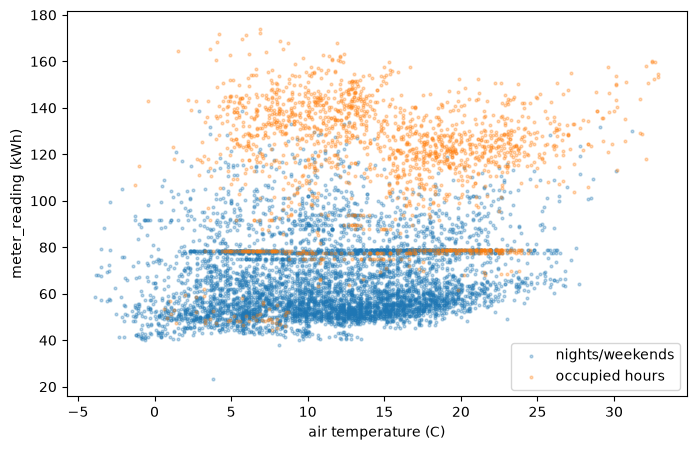

unoccupied correlation: 0.136
occupied correlation: 0.004


In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['dow'] = df['timestamp'].dt.dayofweek
df['occupied'] = df['hour'].between(10, 17) & (df['dow'] < 5)

fig, ax = plt.subplots(figsize=(8,5))
for occ, grp in df.groupby('occupied'):
    label = 'occupied hours' if occ else 'nights/weekends'
    ax.scatter(grp['air_temperature'], grp['meter_reading'], s=4, alpha=0.3, label=label)
ax.set_xlabel('air temperature (C)'); ax.set_ylabel('meter_reading (kWh)')
ax.legend()
plt.show()

for occ, grp in df.groupby('occupied'):
    label = 'occupied' if occ else 'unoccupied'
    print(f"{label} correlation: {grp['air_temperature'].corr(grp['meter_reading']):.3f}")


We assume 10 AM–5 PM on weekdays = occupied and all other times = unoccupied. Temperature has a very weak relationship with consumption in both groups, while occupancy appears to have a larger effect.

### monthly avg temp vs monthly avg consumption
zooming out from hourly noise to see if the seasonal shape lines up.


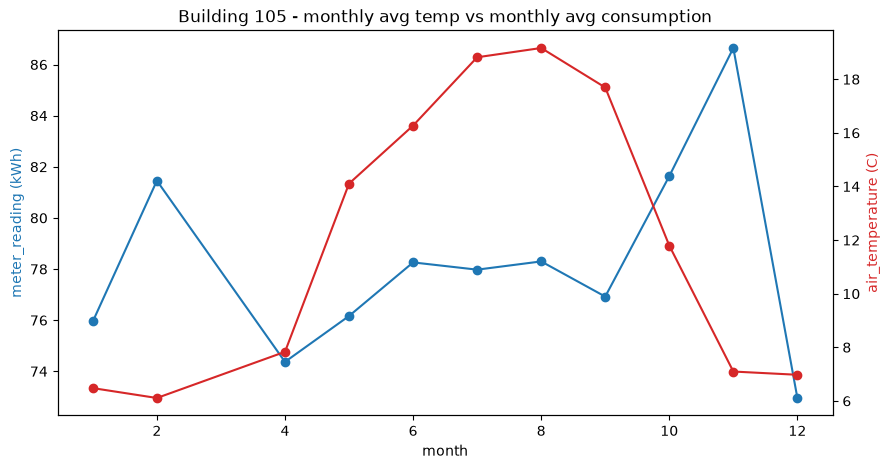

,air_temperature,meter_reading
month,,
1,6.477554,75.953285
2,6.108905,81.456536
4,7.831179,74.369364
5,14.107258,76.164855
6,16.270972,78.260417
7,18.819220,77.976791
8,19.165457,78.299058
9,17.692072,76.923212
10,11.794086,81.635128


In [ ]:
df['month'] = df['timestamp'].dt.month
monthly = df.groupby('month')[['air_temperature', 'meter_reading']].mean()

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.plot(monthly.index, monthly['meter_reading'], color='tab:blue', marker='o', label='avg meter_reading')
ax2.plot(monthly.index, monthly['air_temperature'], color='tab:red', marker='o', label='avg air_temperature')
ax1.set_xlabel('month'); ax1.set_ylabel('meter_reading (kWh)', color='tab:blue')
ax2.set_ylabel('air_temperature (C)', color='tab:red')
ax1.set_title('Building 105 - monthly avg temp vs monthly avg consumption')
plt.show()

monthly


Consumption does not closely follow temperature. This suggests building usage or the academic calendar may have a stronger effect.